# Домашнее задание: вейвлет-когерентность физиологических сигналов

Даны **три ряда измерений** — `data/measurement1.csv`, `data/measurement2.csv`,
`data/measurement3.csv` (столбцы `time_s,value`, частота дискретизации 10 Гц,
длительность 300 с).

Эти три ряда на первый взгляд разные, однако вейвлет-когерентность позволяет увидеть, что некоторые из них
имеют общие ритмы.

Нужно:

* определить, какие **две** записи связаны между собой, а какая — нет;
* найти **две общие частоты**
* определить, **в какие моменты времени связь есть, когда она пропадает и
  когда появляется снова** — причём по самим рядам это не видно;
* сделать практические выводы.


## 0. Подготовка

Ниже заданы вспомогательные функции (менять не нужно):

* `load_series(path)` — читает CSV, возвращает `fs, t, x`;
* `wavelet_power(x, fs)` — вейвлет-мощность `|W|^2` (ось частот возрастает);
* `wavelet_coherence(x1, x2, fs)` — вейвлет-когерентность и фаза;
* `plot_series`, `plot_scalogram`, `plot_coherence` — графики.

Анализируемая полоса: **0.1–1.5 Гц**.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import pycwt
from pycwt import Morlet

FMIN, FMAX, DJ = 0.1, 1.5, 1 / 12
FREQ_TICKS = [0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.7, 1.0, 1.2, 1.5]


def load_series(path):
    data = np.loadtxt(path, delimiter=",", skiprows=1)
    t, x = data[:, 0], data[:, 1]
    fs = 1.0 / (t[1] - t[0])
    return fs, t, x


def _scales(fs, fmin=FMIN, fmax=FMAX, dj=DJ):
    w = Morlet()
    s0 = 1.0 / (fmax * w.flambda())
    J = int(round(np.log2(fmax / fmin) / dj))
    return w, dj, s0, J


def wavelet_power(x, fs):
    w, dj, s0, J = _scales(fs)
    W, sj, freqs, coi, _, _ = pycwt.cwt(x, 1 / fs, dj=dj, s0=s0, J=J, wavelet=w)
    return freqs[::-1], (np.abs(W) ** 2)[::-1], coi


def wavelet_coherence(x1, x2, fs):
    w, dj, s0, J = _scales(fs)
    WCT, aWCT, coi, freqs, _ = pycwt.wct(x1, x2, 1 / fs, dj=dj, s0=s0, J=J,
                                         wavelet=w, sig=False)
    return freqs[::-1], WCT[::-1], aWCT[::-1], coi


def _freq_axis(ax):
    # Ось частот: явные насечки + вторичная ось в «событиях в минуту» + сетка.
    ax.set_yscale("log")
    ax.set_ylim(FMIN, FMAX)
    ax.set_yticks(FREQ_TICKS)
    ax.set_yticklabels([f"{v:g}" for v in FREQ_TICKS])
    ax.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs="all"))
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    sec = ax.secondary_yaxis(
        "right", functions=(lambda f: f * 60.0, lambda b: b / 60.0))
    sec.set_ylabel("событий/мин")
    sec.set_yticks(FREQ_TICKS)
    sec.set_yticklabels([f"{v * 60:g}" for v in FREQ_TICKS])
    ax.grid(True, axis="y", which="major", alpha=0.35, ls=":")
    ax.grid(True, axis="y", which="minor", alpha=0.12, ls=":")
    ax.grid(True, axis="x", which="major", alpha=0.30, ls=":")
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(20))
    ax.grid(True, axis="x", which="minor", alpha=0.12, ls=":")


def plot_series(t, series, labels):
    fig, axs = plt.subplots(len(series), 1, sharex=True, figsize=(11, 6))
    for ax, x, lab in zip(axs, series, labels):
        ax.plot(t, x, lw=0.5)
        ax.set_ylabel(lab)
    axs[-1].set_xlabel("время, с")
    fig.tight_layout()
    return axs


def plot_scalogram(t, freqs, power, title):
    fig, ax = plt.subplots(figsize=(11, 4.5))
    mesh = ax.pcolormesh(
        t, freqs, power, cmap="magma", shading="auto",
        norm=mcolors.LogNorm(vmin=power.max() * 1e-4, vmax=power.max()))
    ax.set_xlabel("время, с")
    ax.set_ylabel("частота, Гц")
    ax.set_title(title)
    _freq_axis(ax)
    fig.colorbar(mesh, ax=ax, pad=0.17, label="вейвлет-мощность")
    fig.tight_layout()
    return ax


def plot_coherence(t, freqs, WCT, aWCT, title):
    fig, ax = plt.subplots(figsize=(11, 4.5))
    mesh = ax.pcolormesh(t, freqs, WCT, cmap="jet", vmin=0, vmax=1,
                         shading="auto")
    T, F = np.meshgrid(t, freqs)
    di = max(1, WCT.shape[0] // 20)
    dj2 = max(1, WCT.shape[1] // 50)
    ax.quiver(T[::di, ::dj2], F[::di, ::dj2],
              np.cos(aWCT[::di, ::dj2]), np.sin(aWCT[::di, ::dj2]),
              color="k", pivot="mid", width=0.002)
    ax.set_xlabel("время, с")
    ax.set_ylabel("частота, Гц")
    ax.set_title(title)
    _freq_axis(ax)
    fig.colorbar(mesh, ax=ax, pad=0.17, label="вейвлет-когерентность")
    fig.tight_layout()
    return ax

## 1. Загрузка и осциллограммы

Загрузите три ряда и постройте их во времени.

fs = 10.0 Гц, длительность = 300 с


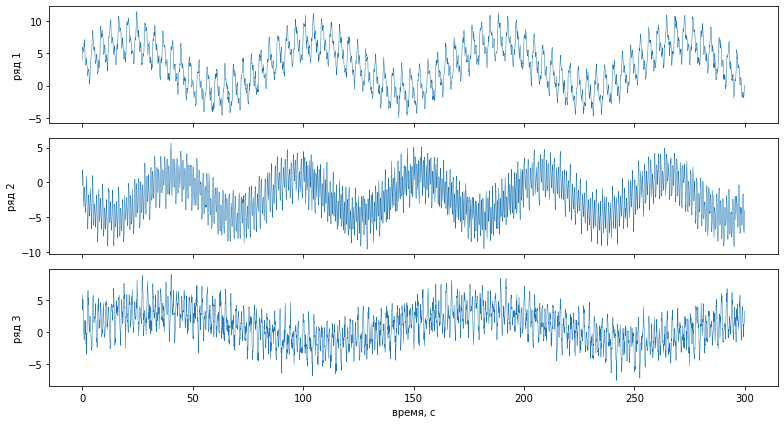

In [5]:
fs, t, x1 = load_series("data/measurement1.csv")
_, _, x2 = load_series("data/measurement2.csv")
_, _, x3 = load_series("data/measurement3.csv")
print(f"fs = {fs} Гц, длительность = {len(x1) / fs:.0f} с")

plot_series(t, [x1, x2, x3], ["ряд 1", "ряд 2", "ряд 3"])
plt.show()

### Задача 1

Похожи ли ряды друг на друга «на глаз»? Сколько среди них, по-вашему,
связанных пар?

**Ответ 1:**

## 2. Вейвлет-спектрограммы

Постройте вейвлет-спектрограммы `|W|^2` для всех трёх рядов. Основные ритмы
видны как яркие горизонтальные полосы (или как траектории, если частота
меняется во времени).

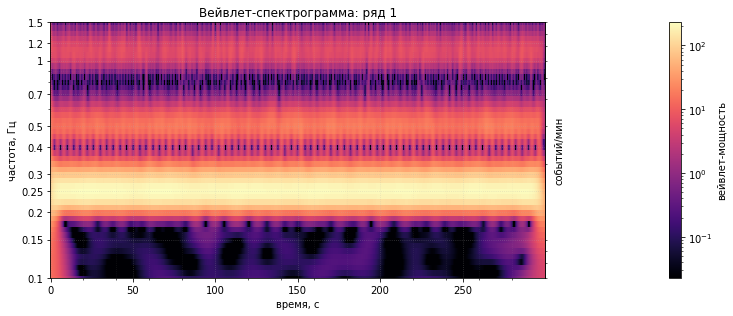

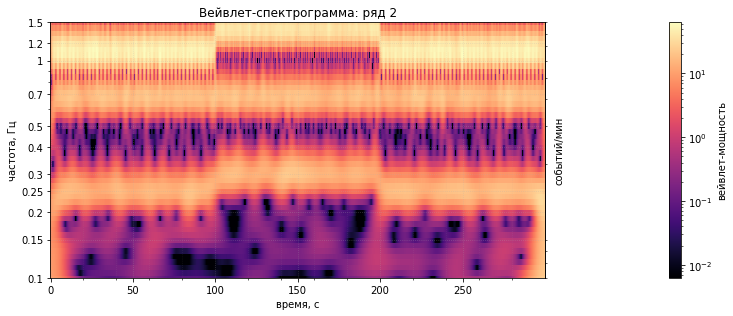

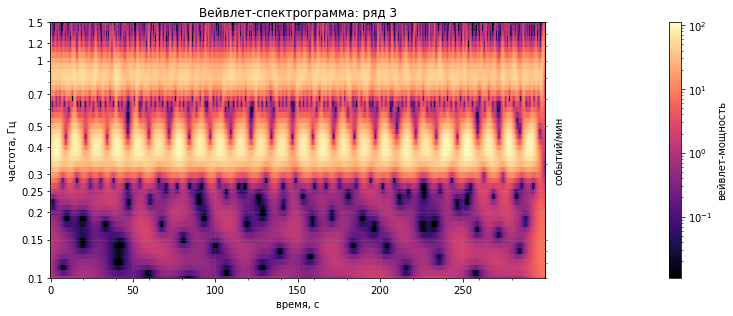

In [6]:
for x, name in [(x1, "ряд 1"), (x2, "ряд 2"), (x3, "ряд 3")]:
    f, p, _ = wavelet_power(x, fs)
    plot_scalogram(t, f, p, "Вейвлет-спектрограмма: " + name)
plt.show()

### Задача 2

В каком диапазоне частот сосредоточена энергия каждого ряда? Есть ли у рядов
несколько характерных ритмов? Совпадают ли они у разных рядов?

**Ответ 2:**

## 3. Вейвлет-когерентность

Посчитайте вейвлет-когерентность для трёх пар: 1–2, 1–3, 2–3. Значение
когерентности близко к 1 там, где ряды согласованы по фазе (общий ритм), и
близко к 0 там, где связи нет. Стрелки показывают фазовый сдвиг.

**Нас интересует не только «на какой частоте», но и «в какие моменты»!**

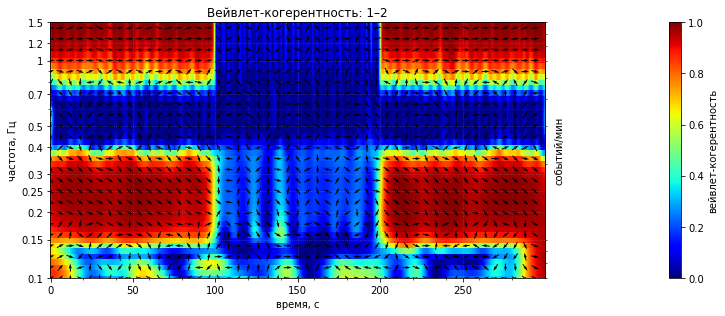

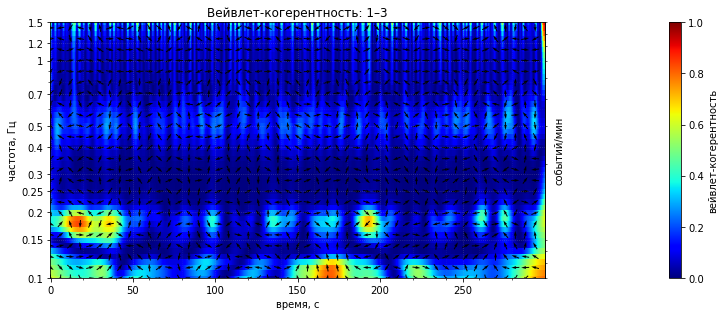

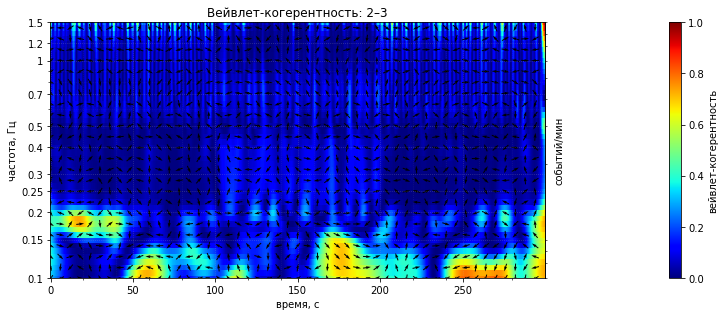

In [7]:
pairs = [("1–2", x1, x2), ("1–3", x1, x3), ("2–3", x2, x3)]
for name, a, b in pairs:
    f, WCT, aWCT, _ = wavelet_coherence(a, b, fs)
    plot_coherence(t, f, WCT, aWCT, "Вейвлет-когерентность: " + name)
plt.show()

### Задача 3

Какая пара рядов **связана** (то есть имеет участки с высокой
когерентностью)? А для каких пар когерентности нет нигде?

**Ответ 3:**

### Задача 4

Определите **две общие частоты** связанной пары (Гц).


**Ответ 4:**

### Задача 5

Посмотрите на карту когерентности связанной пары **вдоль времени**.

**Когда связь пропадает и когда появляется снова?** Укажите приблизительные
моменты времени (в секундах) для начала и конца «разрыва».

Обратите внимание: по самим рядам (графики во времени) этот разрыв **не
виден** — он проявляется только в когерентности.

**Ответ 5:**